In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [3]:
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad"

In [5]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

adata = adata[adata.obs["broad_type"].isin(
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC']
)]

# Remove unmapped genes
#adata.var.index = adata.var.gene_name
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:50: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cell_id"] = adata.obs.index


In [6]:
adata.obs["broad_type"].value_counts()

broad_type
T cells      61766
Monocytes    48439
NK cells     18005
B cells      13371
mDC           2361
pDC            849
Name: count, dtype: int64

In [7]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
                       index_col=0)

# Map genes to ensembl id (required for geneformer)
hoek_bulk.index = gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" )

# Drop unmapped genes 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()]

In [8]:
sig_mat = create_signature_matrix(adata = adata,
                                     sample_col = "batch", # sample id column
                                     cell_type_col = "broad_type",
                                     groupby = "broad_type",
                                     output_path = None)

# Transpose for embedding extraction
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:256: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


In [9]:
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv",
                          index_col=0)

ground_truth = ground_truth.T

In [10]:
def harmonize_columns(df):
    df = df.copy()
    # Merge pDC into mDC (only if both present)
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:            # pDC alone -> treat as mDC
        df = df.rename(columns={"pDC": "mDC"})
    # Rename T cells -> T cell
    df = df.rename(columns={"T cells": "T cell"})
    return df

In [11]:
sig_mat.head()

,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899,ENSG00000245105,ENSG00000166535,ENSG00000256661,ENSG00000128274,ENSG00000094914,ENSG00000081760,...,ENSG00000086827,ENSG00000174442,ENSG00000122952,ENSG00000198205,ENSG00000198455,ENSG00000070476,ENSG00000203995,ENSG00000162378,ENSG00000159840,ENSG00000074755
broad_type,,,,,,,,,,,,,,,,,,,,,
B cells,0.217336,0.031785,0.000449,0.001496,0.004861,0.000075,0.000075,0.000224,0.057737,0.020866,...,0.032458,0.030289,0.003814,0.025727,0.037170,0.096328,0.004637,0.127590,0.090420,0.176651
Monocytes,0.349243,0.037201,0.000062,0.002642,0.007680,0.000784,0.000186,0.000165,0.082413,0.031504,...,0.060199,0.033031,0.007411,0.010013,0.025290,0.177357,0.000145,0.337621,1.442515,0.315180
NK cells,0.086643,0.009497,0.000167,0.009497,0.040878,0.000111,0.000000,0.000222,0.059317,0.033824,...,0.036434,0.038545,0.004610,0.012996,0.022771,0.086754,0.000389,0.081811,0.359733,0.264982
T cells,0.267866,0.019023,0.000210,0.009827,0.036493,0.000097,0.000000,0.000227,0.055969,0.025775,...,0.029304,0.025435,0.013826,0.015267,0.027831,0.079575,0.000372,0.130606,0.267008,0.185847
mDC,0.357899,0.058450,0.000000,0.022025,0.024989,0.000424,0.000000,0.000000,0.122829,0.050402,...,0.111817,0.036849,0.022025,0.015671,0.037696,0.120288,0.000000,0.199068,1.050402,0.160102


In [12]:
hoek_bulk.T.head()

,ENSG00000215529,ENSG00000178605,ENSG00000172771,ENSG00000121410,ENSG00000148584,ENSG00000078328,ENSG00000134864,ENSG00000166535,ENSG00000175899,ENSG00000128274,...,ENSG00000086827,ENSG00000174442,ENSG00000122952,ENSG00000198205,ENSG00000198455,ENSG00000070476,ENSG00000203995,ENSG00000162378,ENSG00000159840,ENSG00000074755
HD30_PBMC_0,35,1519,16,177,1,0,170,66,61,2,...,347,224,81,128,380,3422,89,877,9428,5163
HD30_PBMC_1,35,2125,21,254,1,0,143,55,67,0,...,346,236,77,162,370,3661,84,795,13027,5945
HD30_PBMC_3,30,1630,10,247,1,0,158,68,65,1,...,325,244,97,162,441,3351,97,910,9116,5306
HD30_PBMC_7,26,1868,20,248,0,0,108,53,74,0,...,303,227,103,159,395,3511,99,784,8798,5217
HD31_PBMC_0,41,2154,18,296,1,0,148,63,112,1,...,425,312,96,168,546,4186,114,1167,13388,6362


## Zero-Shot 

In [14]:
# layer_results = {}
# metric_rows = []
# celltype_rows = []

# for layer in range(1, 19):
#     print(f"=== layer {layer} ===", flush=True)

#     sig_mat_gf_embed = extract_embs(
#         bulk_df=sig_mat,
#         mode="geneformer",
#         temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
#         model_path="ctheodoris/Geneformer",
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )

#     gf_embed = extract_embs(
#         bulk_df=hoek_bulk.T,
#         mode="geneformer",
#         temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
#         model_path="ctheodoris/Geneformer",
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )

#     results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
#     results = {solver: harmonize_columns(df) for solver, df in results.items()}

#     layer_results[layer] = results
    
#     # score each solver against ground truth
#     for solver, df in results.items():
#         samples = df.index.intersection(ground_truth.index)
#         celltypes = df.columns.intersection(ground_truth.columns)
    
#         P = df.loc[samples, celltypes].astype(float)
#         T = ground_truth.loc[samples, celltypes].astype(float)
    
#         # --- overall (flattened across all samples x celltypes) ---
#         p = P.values.ravel()
#         t = T.values.ravel()
#         ok = np.isfinite(p) & np.isfinite(t)
    
#         # --- per celltype ---
#         for ct in celltypes:
#             a = P[ct].values
#             b = T[ct].values
#             m = np.isfinite(a) & np.isfinite(b)
    
#             # correlation is undefined if either vector is constant
#             if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
#                 r_ct = np.corrcoef(a[m], b[m])[0, 1]
#             else:
#                 r_ct = np.nan
    
#             celltype_rows.append({
#                 "layer": layer,
#                 "solver": solver,
#                 "celltype": ct,
#                 "correlation": r_ct,
#                 "rmse": np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan,
#             })
    
#         # mean across celltypes for this layer/solver
#         ct_sub = [r for r in celltype_rows if r["layer"] == layer and r["solver"] == solver]
#         corrs = np.array([r["correlation"] for r in ct_sub], dtype=float)
#         mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
#         mean_rmse = np.nanmean([r["rmse"] for r in ct_sub])
    
#         metric_rows.append({
#             "layer": layer,
#             "solver": solver,
#             "correlation": np.corrcoef(p[ok], t[ok])[0, 1],
#             "rmse": np.sqrt(np.mean((p[ok] - t[ok]) ** 2)),
#             "meanCorrelation": mean_corr,
#             "meanRMSE": mean_rmse,
#         })

# metrics_df  = pd.DataFrame(metric_rows)
# celltype_df = pd.DataFrame(celltype_rows)

# metrics_df.to_csv("../results/layer_sweep_metrics_zeroshot_hoek.csv", index=False)

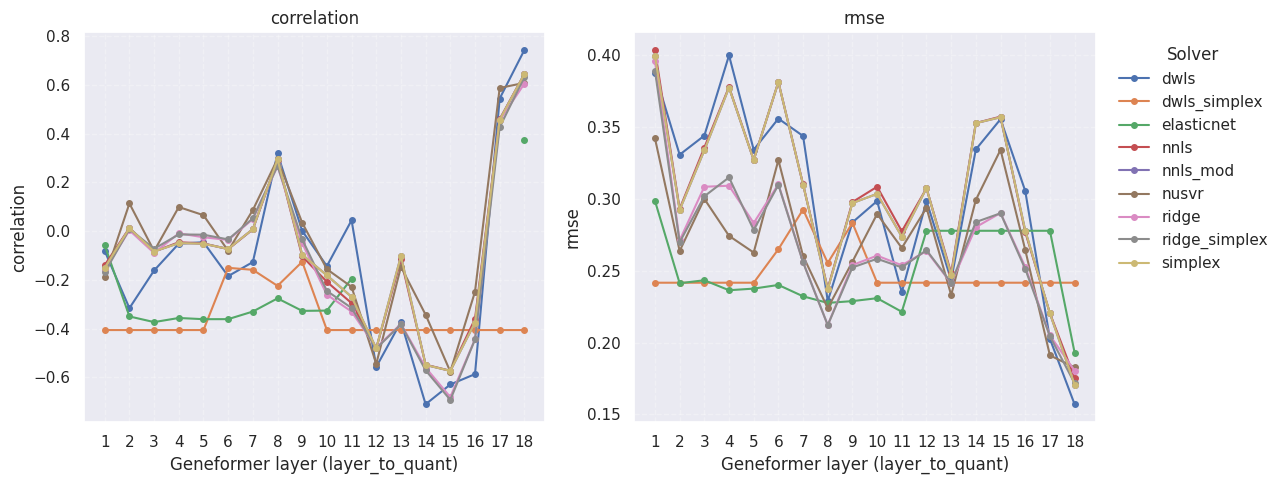

     layer         solver  correlation      rmse  meanCorrelation  meanRMSE
155     18           dwls     0.742730  0.157023         0.628504  0.116155
77       9   dwls_simplex    -0.125702  0.283276         0.324517  0.245107
160     18     elasticnet     0.373308  0.192985         0.689092  0.159537
153     18           nnls     0.643422  0.175443         0.583314  0.131050
154     18       nnls_mod     0.644625  0.170658         0.575124  0.129988
161     18          nusvr     0.608123  0.182691         0.451008  0.144466
159     18          ridge     0.604839  0.180432         0.591390  0.136332
157     18  ridge_simplex     0.631665  0.171665         0.518383  0.131480
156     18        simplex     0.644626  0.170657         0.585134  0.129988


In [15]:
# --- visualize ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["correlation", "rmse"]):
    for solver, sub in metrics_df.groupby("solver"):
        sub = sub.sort_values("layer")
        ax.plot(sub["layer"], sub[metric], marker="o", markersize=4, label=solver)
    ax.set_xlabel("Geneformer layer (layer_to_quant)")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle="--")

axes[1].legend(title="Solver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("../results/layer_sweep_zeroshot_hoek.png", dpi=300, bbox_inches="tight")
plt.show()

# best layer per solver
print(metrics_df.loc[metrics_df.groupby("solver")["correlation"].idxmax()])

# inspect any single layer with your existing plot
#visualize_solvers(layer_results[12], ground_truth, level=["global"])

## Fine-tuned

In [17]:
# layer_results = {}
# metric_rows = []
# celltype_rows = []

# for layer in range(1, 19):
#     print(f"=== layer {layer} ===", flush=True)

#     sig_mat_gf_embed = extract_embs(
#         bulk_df=sig_mat,
#         mode="geneformer",
#         temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
#         model_path="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )

#     gf_embed = extract_embs(
#         bulk_df=hoek_bulk.T,
#         mode="geneformer",
#         temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
#         model_path="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )

#     results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
#     results = {solver: harmonize_columns(df) for solver, df in results.items()}

#     layer_results[layer] = results
    
#     # score each solver against ground truth
#     for solver, df in results.items():
#         samples = df.index.intersection(ground_truth.index)
#         celltypes = df.columns.intersection(ground_truth.columns)
    
#         P = df.loc[samples, celltypes].astype(float)
#         T = ground_truth.loc[samples, celltypes].astype(float)
    
#         # --- overall (flattened across all samples x celltypes) ---
#         p = P.values.ravel()
#         t = T.values.ravel()
#         ok = np.isfinite(p) & np.isfinite(t)
    
#         # --- per celltype ---
#         for ct in celltypes:
#             a = P[ct].values
#             b = T[ct].values
#             m = np.isfinite(a) & np.isfinite(b)
    
#             # correlation is undefined if either vector is constant
#             if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
#                 r_ct = np.corrcoef(a[m], b[m])[0, 1]
#             else:
#                 r_ct = np.nan
    
#             celltype_rows.append({
#                 "layer": layer,
#                 "solver": solver,
#                 "celltype": ct,
#                 "correlation": r_ct,
#                 "rmse": np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan,
#             })
    
#         # mean across celltypes for this layer/solver
#         ct_sub = [r for r in celltype_rows if r["layer"] == layer and r["solver"] == solver]
#         corrs = np.array([r["correlation"] for r in ct_sub], dtype=float)
#         mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
#         mean_rmse = np.nanmean([r["rmse"] for r in ct_sub])
    
#         metric_rows.append({
#             "layer": layer,
#             "solver": solver,
#             "correlation": np.corrcoef(p[ok], t[ok])[0, 1],
#             "rmse": np.sqrt(np.mean((p[ok] - t[ok]) ** 2)),
#             "meanCorrelation": mean_corr,
#             "meanRMSE": mean_rmse,
#         })

# metrics_df  = pd.DataFrame(metric_rows)
# celltype_df = pd.DataFrame(celltype_rows)

# metrics_df.to_csv("../results/layer_sweep_metrics_finetuned_mod2_GF_hoek.csv", index=False)

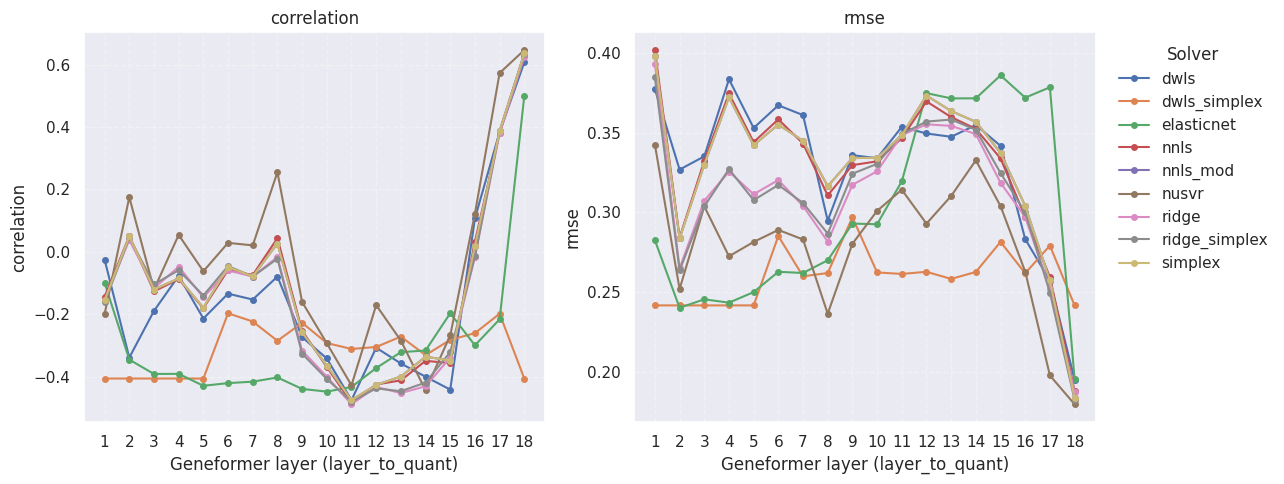

     layer         solver  correlation      rmse  meanCorrelation  meanRMSE
155     18           dwls     0.607353  0.195002         0.385151  0.154746
50       6   dwls_simplex    -0.196780  0.285157         0.136098  0.245151
160     18     elasticnet     0.499408  0.195378         0.553160  0.168709
153     18           nnls     0.627156  0.188040         0.479624  0.149906
154     18       nnls_mod     0.635890  0.183270         0.504019  0.147775
161     18          nusvr     0.646769  0.179529         0.562202  0.143928
159     18          ridge     0.625562  0.187468         0.488231  0.150548
157     18  ridge_simplex     0.635107  0.182413         0.417940  0.147826
156     18        simplex     0.635892  0.183269         0.464227  0.147774


In [18]:
# --- visualize ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["correlation", "rmse"]):
    for solver, sub in metrics_df.groupby("solver"):
        sub = sub.sort_values("layer")
        ax.plot(sub["layer"], sub[metric], marker="o", markersize=4, label=solver)
    ax.set_xlabel("Geneformer layer (layer_to_quant)")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle="--")

axes[1].legend(title="Solver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("../results/layer_sweep_finetuned_hoek.png", dpi=300, bbox_inches="tight")
plt.show()

# best layer per solver
print(metrics_df.loc[metrics_df.groupby("solver")["correlation"].idxmax()])

# inspect any single layer with your existing plot
#visualize_solvers(layer_results[12], ground_truth, level=["global"])